# LaB6 Rietveld Refinement

This notebook demonstrates a full Rietveld refinement workflow for LaB6 using **easyXRD**. It loads the sample and background data, performs baseline correction, sets up GSAS‑II with instrument parameters, iteratively refines background, lattice, instrument parameters, the oxygen atomic site, and finally visualizes the refined pattern.

In [1]:
# Environment configuration and library imports
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import fabio

# Import easyXRD core module
from easyxrd.core import exrd

# Configure plotting parameters
%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.constrained_layout.use"] = True

print(f"Python interpreter : {sys.executable}")
print(f"Working directory  : {Path.cwd()}")
print("easyXRD imported successfully.")


Python interpreter : /home/mt/mpixi/.pixi/envs/default/bin/python
Working directory  : /home/mt/repos/easyXRD_with_agents/01-LaB6/GPT-OSS-120B-Medium
easyXRD imported successfully.


### Load the sample diffraction pattern
The data is loaded with a radial range limited to 1–10 Å to focus on the region of interest.

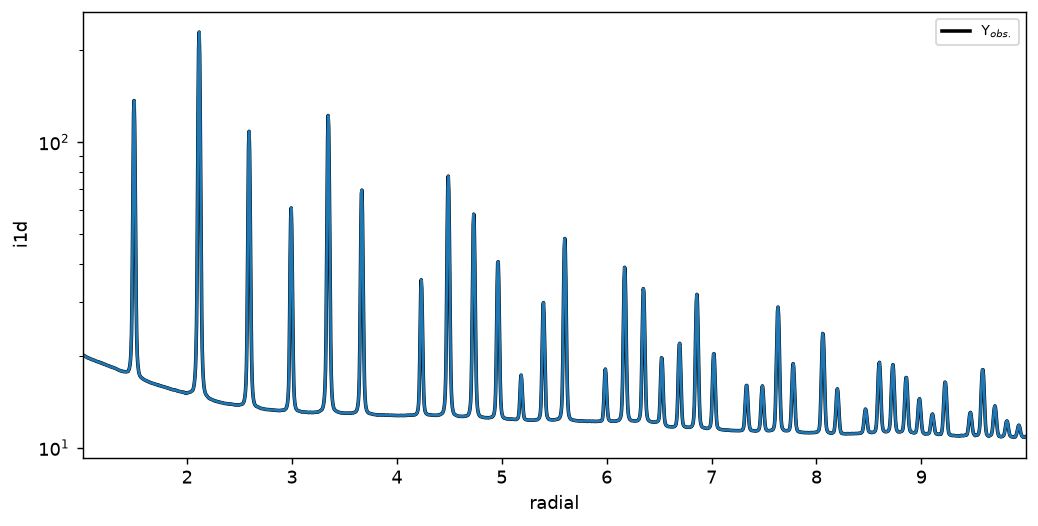

In [2]:
# Initialize easyXRD instance for sample data
sample = exrd(i1d_ylogscale=True, i2d_logscale=False)

# Load 1D diffraction data
sample.load_xrd_data(
    from_txt_file="20260731-124851_A3E69F_count_LaB6_moving.xy",
    txt_file_wavelength_in_angstrom=0.1814,
    radial_range=[1, 10]
)
# Plot the raw 1D pattern (no refinement attributes required)
sample.ds.i1d.plot(); plt.show()


### Load the crystallographic phase
We load the LaB6 CIF file supplied with the examples.

Phase 1: LaB6


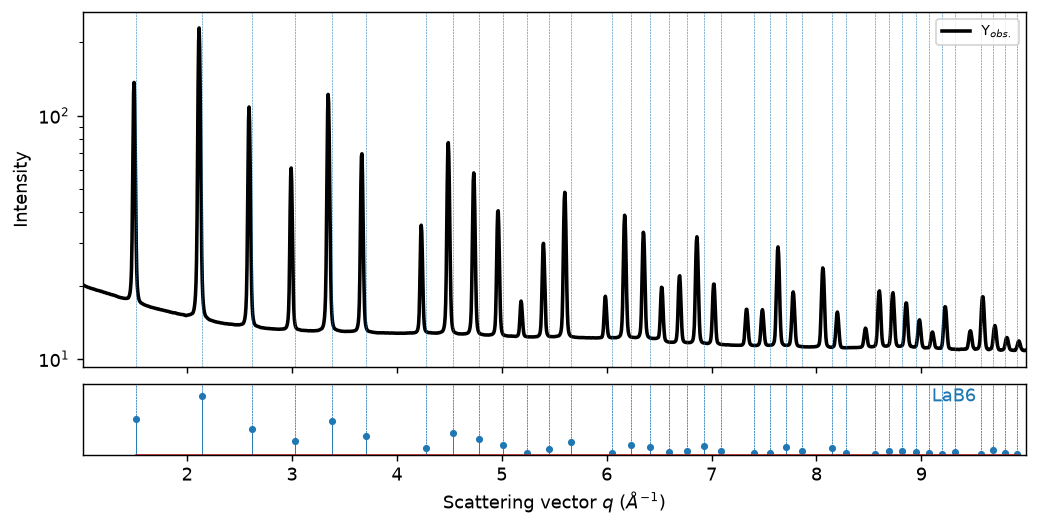

In [ ]:
# # Load phase
# sample.load_phases([
#     "easyXRD_examples/data/LaB6/LaB6_structure_from_MaterialsProject.cif"
# ])
# for i, phase in enumerate(sample.phases):
#     print(f"Phase {i+1}: {phase}")


# Load phase
sample.load_phases([
    {"cif": "easyXRD_examples/data/LaB6/LaB6_structure_from_MaterialsProject.cif", "label": "LaB6"},
])
for i, phase in enumerate(sample.phases):
    print(f"Phase {i+1}: {phase}")

### Load the background pattern
The background (air) pattern will be used for baseline subtraction.

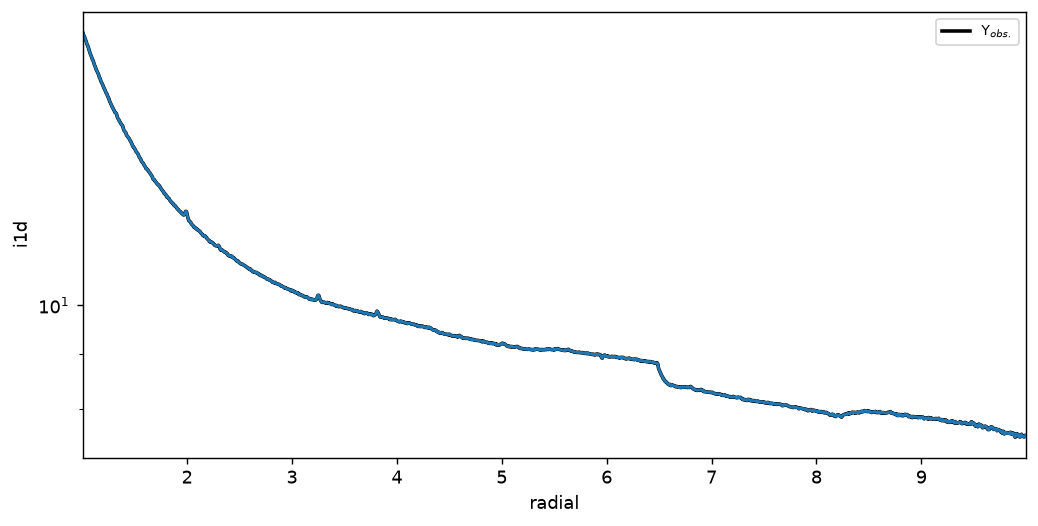

In [4]:
# Load background data
bkg = exrd(i1d_ylogscale=True, i2d_logscale=False)
bkg.load_xrd_data(
    from_txt_file="20260731-111250_935BAC_count_Air.xy",
    txt_file_wavelength_in_angstrom=0.1814,
    radial_range=[1, 10]
)
bkg.ds.i1d.plot(); plt.show()


### Baseline correction using the background
`sample.get_baseline` subtracts the scaled background from the sample and optionally plots the result.

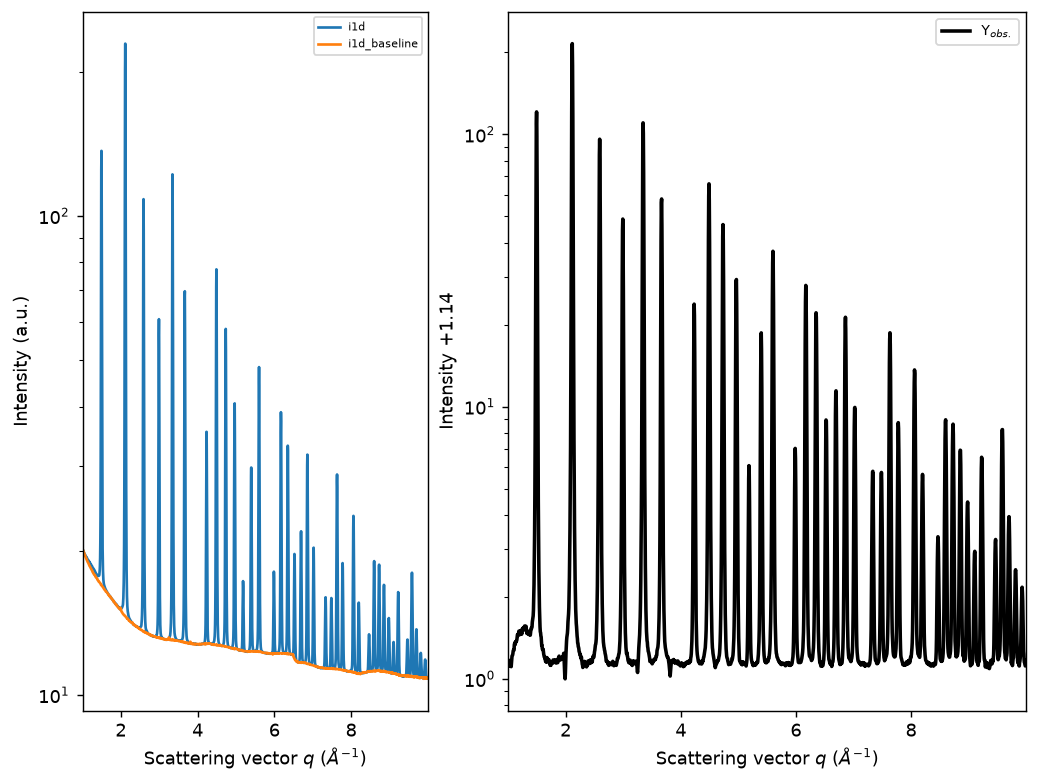

In [5]:
# Baseline using background
sample.get_baseline(input_bkg=bkg, plot=True)


### Set up GSAS‑II refinement
Instrument parameters are read from `_instrument_parameters.gpx`.


 ⏩--1st refinement with LeBail is completed. Rwp/GoF is 99.598/1.757 



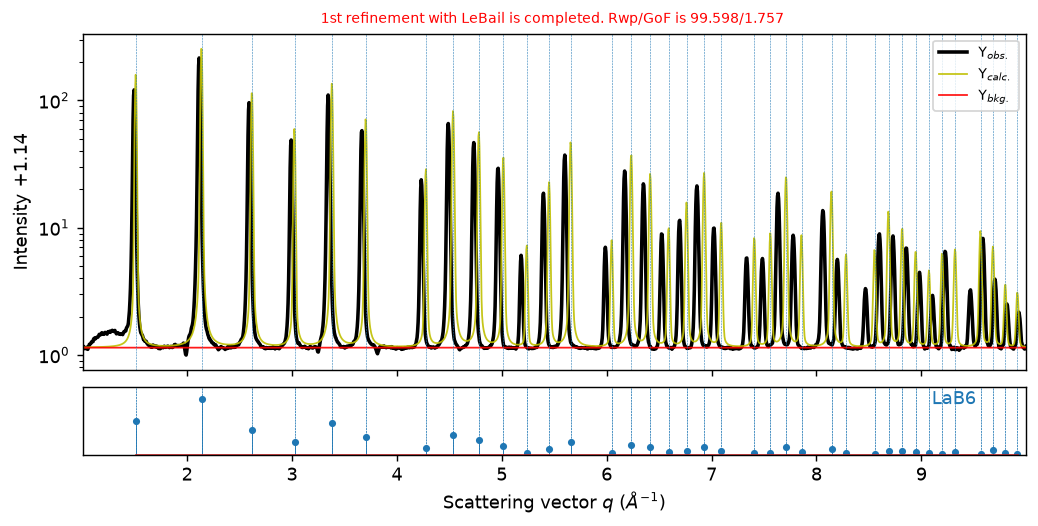

In [6]:
# Setup GSAS-II with instrument parameters from GPX
sample.setup_gsas2_refiner(instprm_from_gpx="_instrument_parameters.gpx")


### Refine the background profile
A Chebyshev polynomial (order 10) is used.

 ✅--Background with 10 coeffs is refined. Rwp/GoF is now 99.526/1.761 (was 99.598(-0.07%)/1.757(0.20%❗))


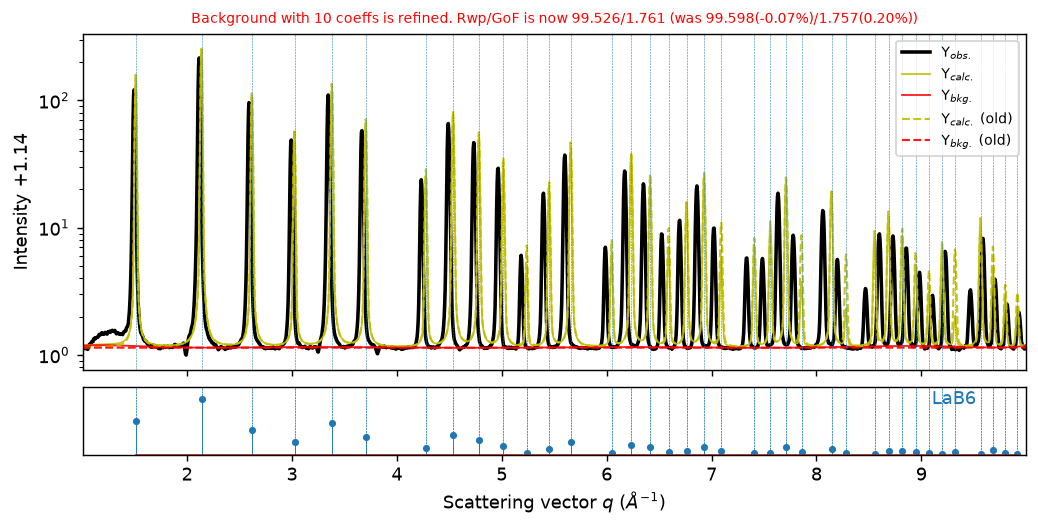

In [7]:
# Refine background
sample.refine_background(num_coeffs=10, background_type="chebyschev-1", plot=True)


### Refine lattice parameters of LaB6

In [8]:
# Refine cell parameters
sample.gpx.set_refinement({
    "set": {
        "Lattice": {
            "refine": True,
            "refine_a": True,
            "refine_b": True,
            "refine_c": True,
            "refine_alpha": True,
            "refine_beta": True,
            "refine_gamma": True
        }
    }
})
refine_str = sample.refine()
print(refine_str)


ValueError: ('Unknown refinement key', 'Lattice')

### Sequential refinement of instrument parameters (U, V, W, X, Y, Z, SH/L, Zero)
Each parameter is refined individually to avoid over‑parameterisation.

In [ ]:
# Refine instrument parameter U
sample.gpx.set_refinement({
    "set": {
        "Instrument Parameters": {
            "U": {"refine": True}
        }
    }
})
print(sample.refine())


In [ ]:
# Refine instrument parameter V
sample.gpx.set_refinement({
    "set": {
        "Instrument Parameters": {
            "V": {"refine": True}
        }
    }
})
print(sample.refine())


In [ ]:
# Refine instrument parameter W
sample.gpx.set_refinement({
    "set": {
        "Instrument Parameters": {
            "W": {"refine": True}
        }
    }
})
print(sample.refine())


In [ ]:
# Refine instrument parameter X
sample.gpx.set_refinement({
    "set": {
        "Instrument Parameters": {
            "X": {"refine": True}
        }
    }
})
print(sample.refine())


In [ ]:
# Refine instrument parameter Y
sample.gpx.set_refinement({
    "set": {
        "Instrument Parameters": {
            "Y": {"refine": True}
        }
    }
})
print(sample.refine())


In [ ]:
# Refine instrument parameter Z
sample.gpx.set_refinement({
    "set": {
        "Instrument Parameters": {
            "Z": {"refine": True}
        }
    }
})
print(sample.refine())


In [ ]:
# Refine instrument parameter SH/L
sample.gpx.set_refinement({
    "set": {
        "Instrument Parameters": {
            "SH/L": {"refine": True}
        }
    }
})
print(sample.refine())


In [ ]:
# Refine instrument parameter Zero
sample.gpx.set_refinement({
    "set": {
        "Instrument Parameters": {
            "Zero": {"refine": True}
        }
    }
})
print(sample.refine())


### Refine background and lattice together (two iterations)
This improves the fit by alternating background and cell refinements.

In [ ]:
# Refine background and cell parameters twice in succession
# First iteration
sample.refine_background(num_coeffs=10, background_type="chebyschev-1", plot=True)
refine_str1 = sample.refine()
print("First cell refinement result:", refine_str1)

# Second iteration
sample.refine_background(num_coeffs=10, background_type="chebyschev-1", plot=True)
refine_str2 = sample.refine()
print("Second cell refinement result:", refine_str2)


### Repeat instrument‑parameter refinements
Ensures all profile parameters are optimised after the previous steps.

In [ ]:
# Repeat the instrument-parameter refinements exactly as before
# U
sample.gpx.set_refinement({
    "set": {
        "Instrument Parameters": {
            "U": {"refine": True}
        }
    }
})
print(sample.refine())
# V
sample.gpx.set_refinement({
    "set": {
        "Instrument Parameters": {
            "V": {"refine": True}
        }
    }
})
print(sample.refine())
# W
sample.gpx.set_refinement({
    "set": {
        "Instrument Parameters": {
            "W": {"refine": True}
        }
    }
})
print(sample.refine())
# X
sample.gpx.set_refinement({
    "set": {
        "Instrument Parameters": {
            "X": {"refine": True}
        }
    }
})
print(sample.refine())
# Y
sample.gpx.set_refinement({
    "set": {
        "Instrument Parameters": {
            "Y": {"refine": True}
        }
    }
})
print(sample.refine())
# Z
sample.gpx.set_refinement({
    "set": {
        "Instrument Parameters": {
            "Z": {"refine": True}
        }
    }
})
print(sample.refine())
# SH/L
sample.gpx.set_refinement({
    "set": {
        "Instrument Parameters": {
            "SH/L": {"refine": True}
        }
    }
})
print(sample.refine())
# Zero
sample.gpx.set_refinement({
    "set": {
        "Instrument Parameters": {
            "Zero": {"refine": True}
        }
    }
})
print(sample.refine())


### Full Rietveld refinement
Refine structure, lattice, and all instrument parameters together.

In [ ]:
# Full Rietveld refinement (refine structure, lattice, and instrument parameters)
sample.gpx.set_refinement({
    "set": {
        "Lattice": {"refine": True},
        "Instrument Parameters": {
            "U": {"refine": True},
            "V": {"refine": True},
            "W": {"refine": True},
            "X": {"refine": True},
            "Y": {"refine": True},
            "Z": {"refine": True},
            "SH/L": {"refine": True},
            "Zero": {"refine": True}
        }
    }
})
refine_str = sample.refine()
print("Rietveld refinement result:", refine_str)


### Refine the oxygen atomic site
We enable refinement of the O coordinates and isotropic displacement parameter.

In [ ]:
# Refine oxygen site parameters (coordinates and isotropic displacement)
phase_name = list(sample.gpx["Phases"].keys())[0]
oxygen_label = None
for atom_label, atom_dict in sample.gpx["Phases"][phase_name]["Atoms"].items():
    if atom_dict["Symbol"] == "O":
        oxygen_label = atom_label
        break
if oxygen_label is None:
    print("No oxygen atom found in the structure.")
else:
    sample.gpx["Phases"][phase_name]["Atoms"][oxygen_label]["refine_xyz"] = True
    sample.gpx["Phases"][phase_name]["Atoms"][oxygen_label]["refine_Uiso"] = True
    refine_str = sample.refine()
    print(f"Refined oxygen site {oxygen_label}: {refine_str}")


### Visualise the final refined pattern

In [ ]:
# Final plot of the refined pattern (data + model)
sample.plot()  # shows observed data, calculated pattern, and residual